# Clinical Trial Site Recommender on the Arango Contextual Data Platform

A new trial protocol comes in. This notebook takes it, finds the most semantically similar
past studies (vector search), traverses the graph to the facilities that ran them (graph
traversal), pulls each site's performance and population context (key-value lookup), and
folds in dosage from the AutoGraph context graph, then ranks the sites with a per-variable
breakdown and a confidence signal.

**This is a demonstration notebook.** It connects to a database that the build scripts have
already populated (`clinical_trial_v2`): studies embedded, facilities enriched with CDC
prevalence and demographics, the graph and vector index in place, and the AutoGraph context
graph built. The heavy, one-time build steps (`ingest.py`, `enrich.py`, `export_docs.py`)
are shown here for reference but are not re-run, so the notebook stays fast and does not
re-hit the external CDC, FCC, and OpenAI ingestion paths.

**Prereqs:** `pip install -r requirements.txt`, a `.env` with your Arango and OpenAI
credentials, and a database already built by the scripts in `src/`.

## 1. Connect

The notebook reads from the already-built database. If the connection succeeds and the
collections report the expected counts, the build is in place and every later cell will run.

In [1]:
import sys, os
_src = os.path.join(os.getcwd(), "src")
if _src not in sys.path:
    sys.path.insert(0, _src)

from dotenv import load_dotenv
from arango import ArangoClient
from openai import OpenAI

load_dotenv()

client = ArangoClient(hosts=os.environ["ARANGO_HOST"])
db = client.db(
    os.environ["ARANGO_DB"],
    username=os.environ["ARANGO_USER"],
    password=os.environ["ARANGO_PASSWORD"],
)
oai = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
print("connected:", db.name)

connected: clinical_trial_v2


In [2]:
for c in ["studies", "facilities", "investigators", "site_relationships"]:
    print(f"{c:20s} {db.collection(c).count():>7,}")

studies                1,688
facilities            23,064
investigators          4,742
site_relationships    27,806


## 2. How the data got here (reference only)

The three build scripts ran once to produce the database this notebook reads. They are
summarized here so the pipeline is legible end to end; **do not re-run them unless you are
rebuilding from scratch**, since they re-embed studies and re-query the external CDC and FCC
services.

**`src/ingest.py`** loads the AACT tables into a graph (studies, facilities, investigators,
conditions, plus the `site_relationships` edges and the `site_topology` named graph), embeds
each study's protocol text with `text-embedding-3-small`, builds the vector index, and
attaches a synthetic performance layer to each facility.

**`src/enrich.py`** adds population context by geography. For each US facility it resolves the
county from the facility's coordinates and attaches that county's real CDC PLACES cancer
prevalence and a demographic age signal. This is a join by geography, not by trial ID.

**`src/export_docs.py`** writes 50 protocol documents for AutoGraph, which builds the context
graph that supplies dosage.

In [3]:
# Reference snippet - the geographic enrichment (already applied; not run here)
#
# county_fips = latlon_to_fips(fac["latitude"], fac["longitude"])
# db.collection("facilities").update({
#     "_key": fac["_key"],
#     "county_fips": county_fips,
#     "cancer_prevalence": prevalence.get(county_fips),   # real, CDC PLACES
#     "median_age": synthetic_median_age(county_fips),    # generated
# })
print("enrichment is already applied; the next cell reads the results.")

enrichment is already applied; the next cell reads the results.


In [4]:
QUERY = """
FOR f IN facilities
    FILTER f.cancer_prevalence != null
    LIMIT 5
    RETURN { name: f.name, city: f.city, prevalence: f.cancer_prevalence, median_age: f.median_age }
"""
for row in db.aql.execute(QUERY):
    print(f"{row['name'][:40]:42s} prev={row['prevalence']}  age={row['median_age']}")

Cleveland Clinic Mercy Hospital            prev=9.4  age=43.3
University Hospitals Seidman Cancer Cent   prev=6.5  age=44.6
Tri-County Hematology & Oncology Associa   prev=9.4  age=43.3
Dana Farber Cancer Institute               prev=6.2  age=41.2
Broad Institute of MIT                     prev=8.1  age=39.5


## 3. The marquee query

One AQL query composes three data models. `APPROX_NEAR_COSINE` searches the vector index for
the five past protocols closest in meaning to the new one (isolated in its own top-level
`SORT`/`LIMIT`, which the function requires). `OUTBOUND ... GRAPH` traverses to the facilities
that ran them. The composite blends four variables into one score. The fifth variable, dosage,
comes separately from the AutoGraph context graph and is stitched in by the resolver.

In [5]:
import sys, os
_src = os.path.join(os.getcwd(), "src")
if _src not in sys.path:
    sys.path.insert(0, _src)
from resolver import MARQUEE
print(MARQUEE)


LET similar = (
    FOR s IN studies
        LET sim = APPROX_NEAR_COSINE(s.embedding, @vec)
        SORT sim DESC
        LIMIT 5
        RETURN {
            nct_id: s.nct_id, title: s.brief_title, phase: s.phase,
            summary: s.summary, eligibility_criteria: s.eligibility_criteria,
            similarity: sim
        }
)

LET sites = (
    FOR study IN similar
        FOR v IN 1..@depth OUTBOUND CONCAT("studies/", study.nct_id) GRAPH "site_topology"
            FILTER IS_SAME_COLLECTION("facilities", v)
            FILTER v.success_score != null
            LET has_geo = v.cancer_prevalence != null
            LET prevalence_score = has_geo ? (v.cancer_prevalence / 15) : @neutral_prev
            LET age_score = (has_geo AND v.median_age != null)
                            ? ((50 - ABS(v.median_age - 40)) / 50) : @neutral_age
            LET composite = (study.similarity * @w_protocol)
                          + (v.success_score  * @w_perf)
                          + (pr

## 4. Fire a placement

`resolve()` embeds the incoming protocol, runs the marquee query, calls the AutoGraph
Retriever for dosage, and composes the ranked recommendation. The sample protocol is a
Phase III palbociclib study in HR-positive, HER2-negative breast cancer.

In [7]:
import sys, os
_src = os.path.join(os.getcwd(), "src")
if _src not in sys.path:
    sys.path.insert(0, _src)
import json
from resolver import resolve, score_breakdown

with open("data/protocol_sample.json") as f:
    protocol = json.load(f)

result = resolve(db, oai, protocol)

embedding protocol...
querying arango (protocol + performance + prevalence + age)...
found 5 similar studies, 10 ranked sites
retrieving dosage context (AutoGraph)...
  dosage: ok
generating reasoning...


In [8]:
for i, s in enumerate(result["top_sites"], 1):
    print(f"\n{i}. {s['name']} -- {s['city']}, {s['country']}   overall {round(s['composite_score'],3)}")
    for key, (val, wt) in score_breakdown(s).items():
        print(f"     {key:22s} {val:<6} ({int(wt*100)}%)")


1. Avera Cancer Institute-Aberdeen -- Aberdeen, United States   overall 0.847
     protocol_similarity    0.826  (35%)
     site_success           0.97   (30%)
     disease_prevalence     0.62   (20%)
     age_match              0.956  (15%)

2. Marin Cancer Center -- Greenbrae, United States   overall 0.845
     protocol_similarity    0.826  (35%)
     site_success           0.91   (30%)
     disease_prevalence     0.7    (20%)
     age_match              0.95   (15%)

3. CAMC Cancer Center -- Charleston, United States   overall 0.844
     protocol_similarity    0.826  (35%)
     site_success           0.92   (30%)
     disease_prevalence     0.66   (20%)
     age_match              0.982  (15%)


In [9]:
print("=== EVIDENCE ===")
for e in result["evidence_passages"]:
    print(f"- {e['study']} (similarity {e['similarity']})")

print("\n=== DOSAGE EVIDENCE ===")
for line in (result["dosage_lines"] or ["unavailable"]):
    print(f"- {line}")

print("\n=== REASONING ===")
print(result["reasoning"])

print("\n=== CONFIDENCE ===")
print(result["confidence"], "--", result["confidence_notes"])

print("\n=== STATS ===")
for k, v in result["stats"].items():
    print(f"  {k}: {v}")

=== EVIDENCE ===
- PALbociclib CoLlaborative Adjuvant Study (similarity 0.826)
- A Real-life Study to Understand the Use and Effects of Palbociclib in US Patients With Breast Cancer (similarity 0.81)
- Abemaciclib, Palbociclib or Dalpiciclib Combined with Endocrine Therapy As First-line Treatment in HR Positive, HER2 Negative Unresectable or Metastatic Breast Cancer (similarity 0.809)

=== DOSAGE EVIDENCE ===
- Fulvestrant: Administered intramuscularly or intravenously; dosing schedules adhere to study protocols but generally given as 500 mg IM on days 1, 15, 29
- Letrozole: 2.5 mg orally once daily, often combined with agents such as ARV-471 or ribociclib [1]
- Z-endoxifen: 10-80 mg orally once daily, sometimes combined with abemaciclib 150 mg BID [1]

=== REASONING ===
The top site, Avera Cancer Institute-Aberdeen, edges out the runner-up Marin Cancer Center primarily by its higher site success score, which compensates for Marin's stronger disease prevalence. Although Marin has a sli

## 5. Why the semantic match matters
The closest past study to a palbociclib-only protocol is a trial testing three different
CDK4/6 inhibitors. The two share almost no exact wording, so keyword search would miss it;
the vector search finds it through shared clinical meaning. What makes this work is that
Arango runs that semantic match and the graph traversal in the same query, so the
recommendation reflects both what a protocol means and how sites connect to relevant trials.

In [10]:
for s in result["similar_studies"][:5]:
    print(f"{round(s['similarity'],3)}  {s['title'][:70]}")

0.826  PALbociclib CoLlaborative Adjuvant Study
0.81  A Real-life Study to Understand the Use and Effects of Palbociclib in 
0.809  Abemaciclib, Palbociclib or Dalpiciclib Combined with Endocrine Therap
0.784  Clinical Trial Assessing the Safety of Neoadjuvant Palbociclib in Comb
0.776  Palbociclib and Endocrine Therapy for LObular Breast Cancer Preoperati


## 6. Visualizing the recommendation

Four figures, all saved to `assets/` for the README and the article:

1. **Topology** - one study and the facilities connected to it, the shape the recommender walks.
2. **Score breakdown** - each top site's per-variable contribution to its composite score.
3. **Similarity scores** - how close each retrieved study is to the new protocol (the vector stage).
4. **Site tradeoff** - prevalence vs. performance across all candidates, dot size by overall score.

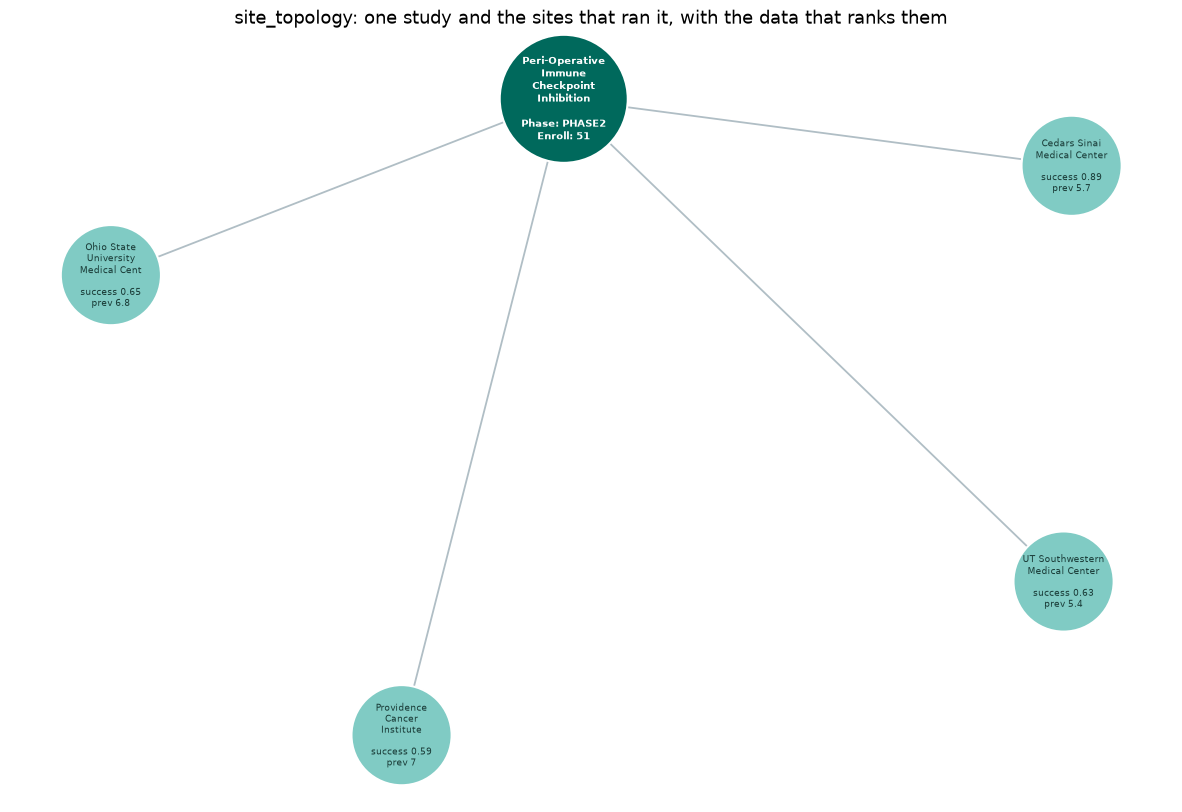

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import textwrap, os
import warnings
warnings.filterwarnings("ignore")

os.makedirs("assets", exist_ok=True)

# One study plus the performance + prevalence on each connected site.
# We require enriched (US) sites so every node shows real ranking data.
FOCUS_Q = """
FOR s IN studies
    SORT RAND()
    LIMIT 1
    LET sites = (
        FOR v IN 1..1 OUTBOUND s._id GRAPH "site_topology"
            FILTER IS_SAME_COLLECTION("facilities", v)
            FILTER v.success_score != null
            FILTER v.cancer_prevalence != null
            LIMIT 8
            RETURN {
                name: v.name,
                success: v.success_score,
                prevalence: v.cancer_prevalence
            }
    )
    FILTER LENGTH(sites) >= 3
    RETURN {
        study: s.brief_title,
        phase: s.phase,
        enrollment: s.enrollment,
        sites: sites
    }
"""

rec = list(db.aql.execute(FOCUS_Q))
while not rec:
    rec = list(db.aql.execute(FOCUS_Q))
rec = rec[0]

# Center label: study title + phase + enrollment (tighter wrap so it fits the circle)
study_title = "\n".join(textwrap.wrap(rec["study"][:44], 16))
phase = rec.get("phase") or "N/A"
enroll = rec.get("enrollment") or "N/A"
center = f"{study_title}\n\nPhase: {phase}\nEnroll: {enroll}"

G = nx.DiGraph()
G.add_node(center, kind="study")
for s in rec["sites"]:
    label = "\n".join(textwrap.wrap(s["name"][:34], 15))
    label += f"\n\nsuccess {s['success']}\nprev {s['prevalence']}"
    G.add_node(label, kind="site")
    G.add_edge(center, label)

colors = ["#00695C" if G.nodes[n]["kind"] == "study" else "#80CBC4" for n in G.nodes]
sizes = [8500 if G.nodes[n]["kind"] == "study" else 5200 for n in G.nodes]

fig, ax = plt.subplots(figsize=(15, 10))
pos = nx.spring_layout(G, seed=42, k=3.2)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#B0BEC5", arrows=True,
                       arrowsize=15, width=1.3)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=sizes,
                       edgecolors="white", linewidths=1.5)
for node, (x, y) in pos.items():
    is_study = G.nodes[node]["kind"] == "study"
    ax.text(x, y, node, fontsize=7.5 if is_study else 6.5,
            ha="center", va="center",
            color="white" if is_study else "#1a3c38",
            fontweight="bold" if is_study else "normal")
ax.set_title("site_topology: one study and the sites that ran it, with the data that ranks them",
             fontsize=13)
ax.axis("off")
plt.savefig("assets/site-topology-graph.png", dpi=150, bbox_inches="tight")
plt.show()

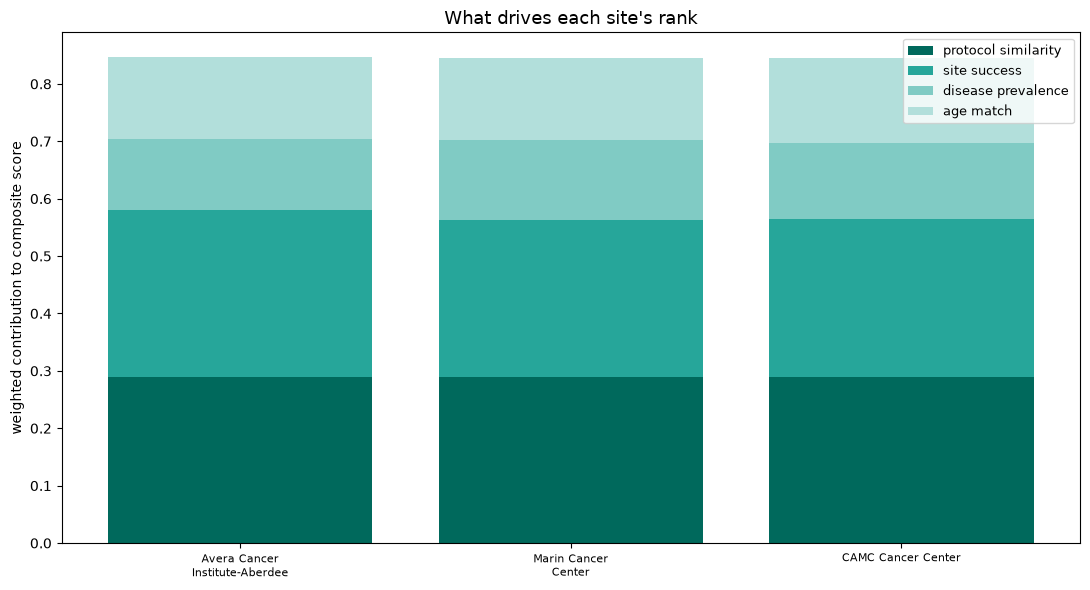

In [12]:
import numpy as np

top = result["top_sites"]
variables = ["protocol_similarity", "site_success", "disease_prevalence", "age_match"]

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(top))
bottom = np.zeros(len(top))
palette = ["#00695C", "#26A69A", "#80CBC4", "#B2DFDB"]

for var, color in zip(variables, palette):
    contribs = []
    for s in top:
        val, wt = score_breakdown(s)[var]
        contribs.append(val * wt)
    ax.bar(x, contribs, bottom=bottom, label=var.replace("_", " "), color=color)
    bottom += np.array(contribs)

ax.set_xticks(x)
ax.set_xticklabels(["\n".join(textwrap.wrap(s["name"][:30], 18)) for s in top], fontsize=8)
ax.set_ylabel("weighted contribution to composite score")
ax.set_title("What drives each site's rank", fontsize=13)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("assets/score-breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

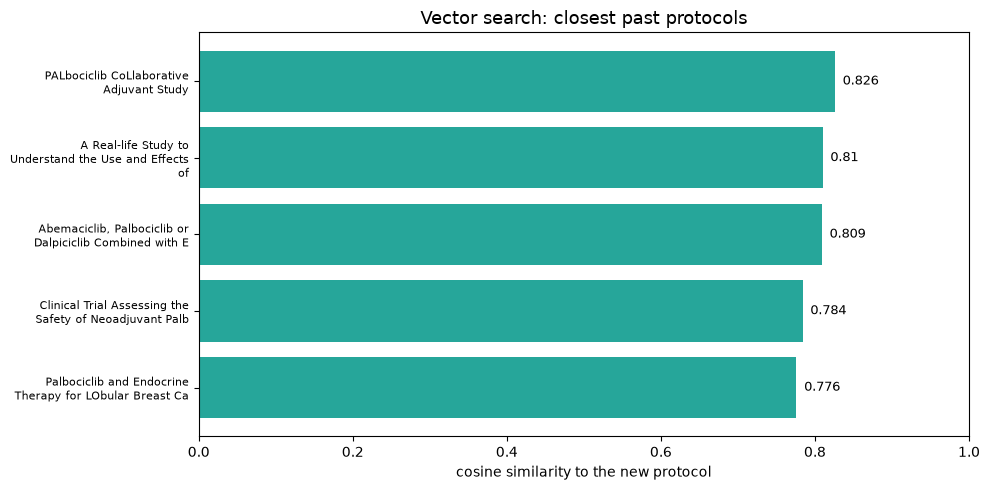

In [13]:
# --- Figure 3: semantic similarity of the top matched studies ---
# Shows the vector-search stage: how close each retrieved study is to the new protocol.
studies = result["similar_studies"][:5]
names = ["\n".join(textwrap.wrap(s["title"][:55], 30)) for s in studies]
sims = [round(s["similarity"], 3) for s in studies]

fig, ax = plt.subplots(figsize=(10, 5))
ypos = np.arange(len(studies))[::-1]
bars = ax.barh(ypos, sims, color="#26A69A")
ax.set_yticks(ypos)
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel("cosine similarity to the new protocol")
ax.set_xlim(0, 1)
ax.set_title("Vector search: closest past protocols", fontsize=13)
for b, s in zip(bars, sims):
    ax.text(b.get_width() + 0.01, b.get_y() + b.get_height()/2, f"{s}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("assets/similarity-scores.png", dpi=150, bbox_inches="tight")
plt.show()

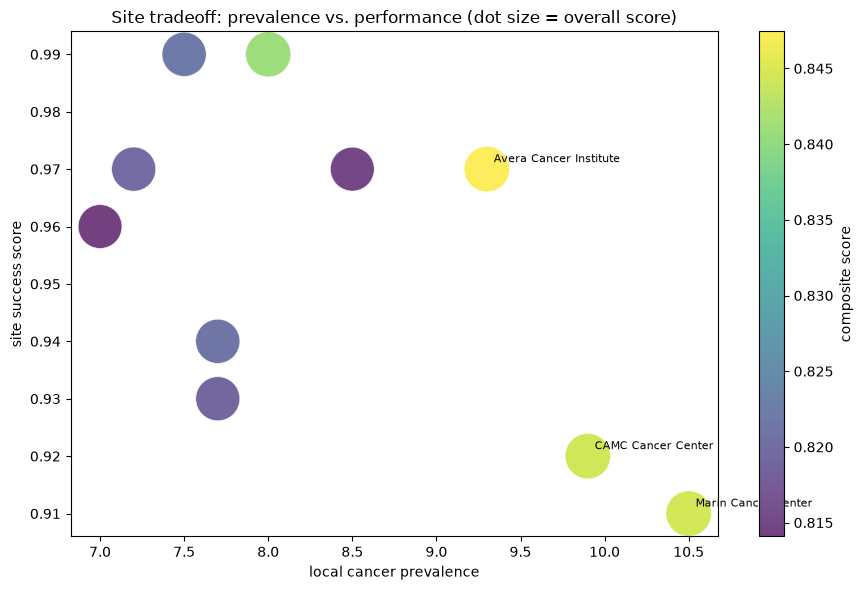

In [14]:
# --- Figure 4: the multi-variable tradeoff across all ranked sites ---
# Each dot is a candidate site: x = local prevalence, y = site success, dot size = overall score.
sites_all = [s for s in result["recommended_sites"] if s.get("prevalence") is not None]
xs = [s["prevalence"] for s in sites_all]
ys = [s["success_score"] for s in sites_all]
sizes = [ (s["composite_score"] ** 2) * 1500 for s in sites_all ]

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(xs, ys, s=sizes, c=[s["composite_score"] for s in sites_all],
                cmap="viridis", alpha=0.75, edgecolors="white", linewidth=0.5)
# label the top 3
for s in result["top_sites"]:
    if s.get("prevalence") is not None:
        ax.annotate(s["name"][:22], (s["prevalence"], s["success_score"]),
                    fontsize=8, xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("local cancer prevalence")
ax.set_ylabel("site success score")
ax.set_title("Site tradeoff: prevalence vs. performance (dot size = overall score)", fontsize=12)
fig.colorbar(sc, label="composite score")
plt.tight_layout()
plt.savefig("assets/site-tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

### The full flow in one picture\n\nThe graph above showed a single study and its sites. This one shows the whole recommendation: the incoming protocol, the five studies closest to it in meaning, and the facilities that ran those studies. It is the pipeline, drawn from the live result.

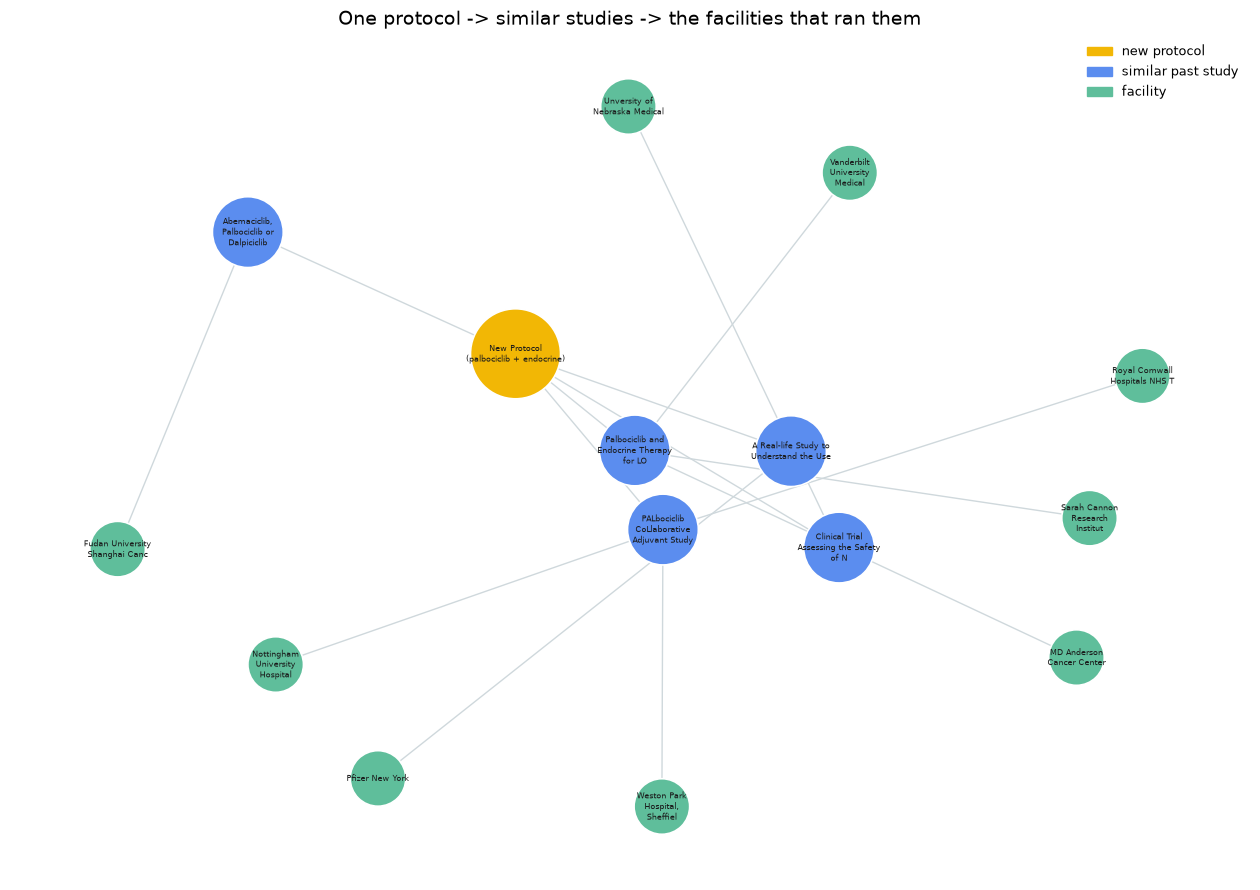

In [15]:
# --- Figure 5: the full flow -- one protocol -> similar studies -> the sites that ran them ---
# This is the whole recommendation in one picture: the incoming protocol (gold), the five
# semantically closest past studies (blue), and the facilities those studies ran at (green).
# Built from the live resolver result, so it reflects the actual recommendation.

sim_studies = result["similar_studies"][:5]

# pull the facilities for each similar study from the graph
flow = {}
for st in sim_studies:
    rows = list(db.aql.execute("""
        FOR v IN 1..1 OUTBOUND CONCAT("studies/", @nct) GRAPH "site_topology"
            FILTER IS_SAME_COLLECTION("facilities", v)
            LIMIT 3
            RETURN v.name
    """, bind_vars={"nct": st["nct_id"]}))
    flow[st["title"]] = rows

protocol_label = "New Protocol\n(palbociclib + endocrine)"

G = nx.DiGraph()
G.add_node(protocol_label, kind="protocol")
for title, sites in flow.items():
    stud = "\n".join(textwrap.wrap(title[:40], 20))
    G.add_node(stud, kind="study")
    G.add_edge(protocol_label, stud)
    for name in sites:
        fac = "\n".join(textwrap.wrap(name[:30], 16))
        G.add_node(fac, kind="site")
        G.add_edge(stud, fac)

palette = {"protocol": "#F2B705", "study": "#5B8DEF", "site": "#5FBE9B"}
colors = [palette[G.nodes[n]["kind"]] for n in G.nodes]
sizes = [{"protocol": 4200, "study": 2600, "site": 1600}[G.nodes[n]["kind"]] for n in G.nodes]

fig, ax = plt.subplots(figsize=(16, 11))
pos = nx.spring_layout(G, seed=7, k=1.4)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#CFD8DC", arrows=True, arrowsize=10, width=1)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=sizes,
                       edgecolors="white", linewidths=1.2)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=6, font_color="#1a1a1a")
ax.set_title("One protocol -> similar studies -> the facilities that ran them", fontsize=14)
ax.axis("off")

# legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=palette["protocol"], label="new protocol"),
                   Patch(color=palette["study"], label="similar past study"),
                   Patch(color=palette["site"], label="facility")],
          loc="upper right", fontsize=9, frameon=False)
plt.savefig("assets/recommendation-flow.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Ask Ada in plain English

Ada reaches the same enriched data without AQL. In the platform, a feasibility lead can ask
for US sites by prevalence and get the population-aware answer that powers this notebook,
proving one contextual store serves both a Python workflow and a natural-language question.

## 8. What this shows

One Arango deployment recommends trial sites end to end: vector search, graph traversal, and
key-value lookup compose in one AQL query for the structured answer, and the AutoGraph context
graph supplies dosage grounded in extracted protocol text. Every recommendation carries a
per-variable breakdown, its evidence, and a confidence signal. Swap the two synthetic layers
(site performance and demographic age) for real operational and census data and the pipeline
runs unchanged, because only the source of those fields changes, not the schema or the query.